# Preparing the critical state of the Transverse-Field Ising Model

The one-dimensional Transverse-Field Ising Model (TFIM) is one of the most studied quantum many-body systems. Its Hamiltonian reads

$$
H_{\text{TFIM}} = -J\sum_{\langle i,j\rangle} \sigma^z_i \sigma^z_j \;-\; h\sum_i \sigma^x_i
$$

At the critical point $h = J$, the system undergoes a quantum phase transition between a ferromagnetic phase ($h < J$) and a paramagnetic phase ($h > J$). The ground state at criticality exhibits long-range entanglement and algebraically-decaying correlations — signatures that make it a demanding benchmark for quantum state preparation.

In this tutorial, we show how to prepare the TFIM critical ground state on a ring of $N = 8$ atoms using **qoolqit**'s Rydberg analog model. We will:

1. Set up a circular register and map the TFIM parameters to Rydberg drive parameters.
2. Design a quasi-adiabatic sweep schedule.
3. Compute the exact ground state via **exact diagonalization** (ED) as a reference.
4. Run the adiabatic preparation with the **`emu_sv`** state-vector backend and compare against the ED target using fidelity, occupation, and correlation functions.


## Setup and imports

We begin by importing the necessary modules. Beyond the core **qoolqit** building blocks (`Drive`, `Register`, `QuantumProgram`, …), we use the `emu_sv` backend which provides exact state-vector propagation — ideal for small systems like $N = 7$ where the full Hilbert space is trivially accessible. For the target ground state, we use `scipy.linalg.eigh` to exactly diagonalize the Rydberg Hamiltonian.


In [1]:
import numpy as np, matplotlib.pyplot as plt, time
from qoolqit import Drive, Interpolated, QuantumProgram, Register, AnalogDevice, DataGraph
from qoolqit.execution import LocalEmulator, Occupation, CorrelationMatrix, EmulationConfig

# emu-sv: exact state-vector backend + observables
from emu_sv import SVBackend, SVConfig, StateResult, Fidelity, StateVector

# Exact diagonalization
from scipy.linalg import eigh
import logging

## Building the register

We place $N = 7$ atoms on a circle using `DataGraph.circle`. This geometry gives periodic boundary conditions, which is the natural setting for studying bulk properties of the TFIM.

The mapping from TFIM parameters to Rydberg drive parameters is:

- **Rabi frequency** $\Omega = h / 2$, which controls the transverse field.
- **Detuning** $\delta$, which is chosen to compensate the interaction shifts so that the effective Ising couplings are correctly reproduced.


In [2]:
N = 8
graph = DataGraph.circle(N)

# TFIM parameters: critical point at h = J = 1
J = 1.0
h = 1.0

# Mapping to Rydberg parameters
OMEGA_R = h / 2  # Rabi frequency

# Detuning compensates the interaction energy: delta = 2 * sum_{j != 0} J_{0j} / 4
DELTA = 2 * sum([y for x, y in graph.interactions().items() if (x[0] == 0 and x[1] != 0)]) / 4

register = Register.from_graph(graph)
device = AnalogDevice()

print(f'N = {N} atoms on a ring')
print(f'Omega = {OMEGA_R:.4f}   Delta = {DELTA:.4f}')

N = 8 atoms on a ring
Omega = 0.5000   Delta = 1.0317


## Designing the quasi-adiabatic schedule

A simple linear sweep often fails near a critical point because the energy gap closes, making the adiabatic condition hard to satisfy. To improve performance we use a **tangent sweep**: the detuning is swept from a large negative value $\delta_0 = -5\,\Omega$ up to the target $\delta$ following a $\tan$-shaped profile. This non-linear schedule slows down near the critical gap, where the system is most sensitive, and speeds up elsewhere.

The schedule has two phases:

1. **Ramp-up** (first `frac_ramp` of the total time): the Rabi frequency $\Omega$ is smoothly turned on while the detuning stays at $\delta_0$.
2. **Detuning sweep** (remaining time): $\Omega$ is held constant and the detuning follows the tangent profile toward $\delta$.


In [3]:
def build_program(T, frac_ramp=0.1, alpha=1.4, n_ctrl=81):
    """Quasi-adiabatic tangent sweep: Omega ramps up, then detuning sweeps to DELTA."""
    d0 = -5.0 * OMEGA_R  # Initial detuning (far-detuned regime)

    # Rabi frequency: smooth ramp-up during the initial fraction of the schedule
    t_om = [0.0, frac_ramp * 0.5, frac_ramp, 1.0]
    om   = [0.0, 0.5 * OMEGA_R, OMEGA_R, OMEGA_R]

    # Detuning: hold at d0 during ramp-up, then tangent sweep
    t_d = [0.0, frac_ramp]
    dv  = [d0, d0]

    # Build the tangent profile for the sweep phase
    s = np.linspace(0.0, 1.0, n_ctrl)
    tan_a = np.tan(alpha)
    sw = d0 + (DELTA - d0) * (1.0 - np.tan(alpha * (1.0 - s)) / tan_a)
    sw[-1] = DELTA  # Ensure we land exactly on the target detuning

    ts = frac_ramp + s * (1.0 - frac_ramp)
    t_d += ts[1:].tolist()
    dv  += sw[1:].tolist()

    return QuantumProgram(register, Drive(
        amplitude=Interpolated(T, values=om, times=t_om),
        detuning=Interpolated(T, values=dv, times=t_d)))

## Computing the target state with exact diagonalization

Before running the adiabatic preparation, we need a reference ground state to compare against. Since $N = 7$ is small enough, we can build the full Rydberg Hamiltonian at the endpoint parameters $(\Omega, \delta)$ and diagonalize it exactly.

The Rydberg Hamiltonian we diagonalize is

$$
H(\Omega, \delta) = \frac{\Omega}{2}\sum_j \sigma^x_j - \delta \sum_j n_j + \sum_{i<j} U_{ij}\, n_i n_j
$$

where $n_j = |1\rangle\langle 1|$ is the Rydberg number operator. The basis convention matches `emu_sv`: site $j$ corresponds to bit $N-1-j$ of the state index (big-endian ordering).


In [4]:
# Build the full interaction matrix from the graph
interactions_dict = graph.interactions()
U = np.zeros((N, N))
for (i, j), val in interactions_dict.items():
    U[i, j] = val
    U[j, i] = val


def build_target_hamiltonian(N, U, omega, delta):
    """Build the dense 2^N x 2^N Rydberg Hamiltonian matrix.

    Convention: basis index I corresponds to the bitstring (b_0 b_1 ... b_{N-1})
    with b_j = bit (N-1-j) of I (site 0 is the MOST significant bit).
    This matches emu-sv's internal layout.
    """
    dim = 1 << N
    idx = np.arange(dim, dtype=np.int64)

    # n_j[I] = bit j of the bitstring -> bit (N-1-j) of the integer I
    occ = np.stack([(idx >> (N - 1 - j)) & 1 for j in range(N)], axis=1)  # (dim, N)

    # Diagonal: -delta * sum_j n_j + sum_{i<j} U_ij n_i n_j
    diag = -delta * occ.sum(axis=1).astype(np.float64)
    for i in range(N):
        for j in range(i + 1, N):
            diag += U[i, j] * occ[:, i] * occ[:, j]

    H = np.diag(diag).astype(np.complex128)

    # Off-diagonal: (omega/2) * sum_j sigma^x_j -> flip bit j
    for j in range(N):
        flip = 1 << (N - 1 - j)
        rows = idx
        cols = idx ^ flip
        H[rows, cols] += 0.5 * omega

    return H


# Diagonalize the target Hamiltonian
H_target = build_target_hamiltonian(N, U, OMEGA_R, DELTA)
evals, evecs = eigh(H_target)
psi_gs = evecs[:, 0].astype(np.complex128)

print(f'E_0 = {evals[0]:.6f},  E_1 = {evals[1]:.6f},  gap = {evals[1] - evals[0]:.6f}')

E_0 = -4.602978,  E_1 = -4.546047,  gap = 0.056931


From the ED ground state we can directly compute the target occupation $\langle n_i \rangle$ and the correlation matrix $\langle n_i n_j \rangle$ for later comparison.


In [5]:
def occupation_and_corr_from_psi(psi, N):
    """Compute <n_i> and <n_i n_j> from a dense state vector."""
    dim = 1 << N
    idx = np.arange(dim)
    bits = np.stack([(idx >> (N - 1 - j)) & 1 for j in range(N)], axis=1)
    p = np.abs(psi)**2
    occ = bits.T @ p
    corr = np.einsum('ki,kj,k->ij', bits, bits, p)
    return occ.real, corr.real


occ_t, corr_t = occupation_and_corr_from_psi(psi_gs, N)
conn_t = corr_t - np.outer(occ_t, occ_t)  # Connected correlations

print(f'Target <n> = {np.mean(occ_t):.4f} (expected ~0.5 at the TFIM critical point)')

Target <n> = 0.5000 (expected ~0.5 at the TFIM critical point)


## Running the adiabatic state preparation

We now run the actual time-evolution under the quasi-adiabatic schedule using the **`emu_sv`** backend (exact state-vector propagation). We request the occupation, correlation matrix, fidelity against the ED ground state, and the final state vector.

To pass the ED ground state as a fidelity reference, we convert it to an `emu_sv.StateVector` object using the `'g'`/`'r'` eigenstates convention.


In [ ]:
# Convert the ED ground state to an emu_sv StateVector for the Fidelity observable
to_gr = lambda s: ''.join('g' if x == '0' else 'r' for x in s)
amplitudes = {
    to_gr(bin(i)[2:].zfill(N)): complex(x)
    for i, x in enumerate(psi_gs)
}
target_state = StateVector.from_state_amplitudes(
    eigenstates=('g', 'r'), amplitudes=amplitudes
)

In [ ]:
T = 100  # Total evolution time for the adiabatic sweep

# Build and compile the program
prog = build_program(T)
prog.compile_to(device, device_max_duration_ratio=1)


# Configure observables
config = EmulationConfig(
    observables=(
        Occupation(evaluation_times=[1.0]),
        CorrelationMatrix(evaluation_times=[1.0]),
        Fidelity(evaluation_times=[1.0], state=target_state),
        StateResult(evaluation_times=[1.0]),
    ),
    log_level=logging.WARN
)

# Run the adiabatic evolution
t0 = time.time()
emulator = LocalEmulator(backend_type=SVBackend, emulation_config=config)
results = emulator.run(prog)

# Extract results
tagged = results[0].get_tagged_results()

occ_p  = np.asarray(tagged['occupation'][-1]).real
corr_p = np.asarray(tagged['correlation_matrix'][-1]).real
conn_p = corr_p - np.outer(occ_p, occ_p)
fid    = float(np.asarray(tagged['fidelity'][-1]).real)

# Also extract the prepared state vector for a direct overlap check
psi_T = tagged['state'][-1].data.cpu().numpy().astype(np.complex128)
fid_check = abs(np.vdot(psi_T, psi_gs))**2

print(f'Adiabatic evolution completed in {time.time()-t0:.1f}s')
print(f'<n> = {np.mean(occ_p):.4f}')
print(f'Fidelity (observable): F = {fid:.4f}')
print(f'Fidelity (direct overlap check): F = {fid_check:.4f}')

Adiabatic evolution completed in 4.9s
<n> = 0.4982
Fidelity (observable): F = 0.9997
Fidelity (direct overlap check): F = 0.9997


## Comparison plots

We now compare the prepared state against the ED target across several observables:

- **Fidelity**: overlap with the exact ground state.
- **Rydberg density** $\langle n_i \rangle$: at the critical point, this should be close to $1/2$ for all sites.
- **Connected correlations** $C_{\text{conn}}(d) = \langle n_i n_{i+d}\rangle - \langle n_i\rangle\langle n_{i+d}\rangle$: these should decay algebraically at criticality.
- **Staggered correlations** $(-1)^d C_{\text{conn}}(d)$: reveal antiferromagnetic ordering tendencies.


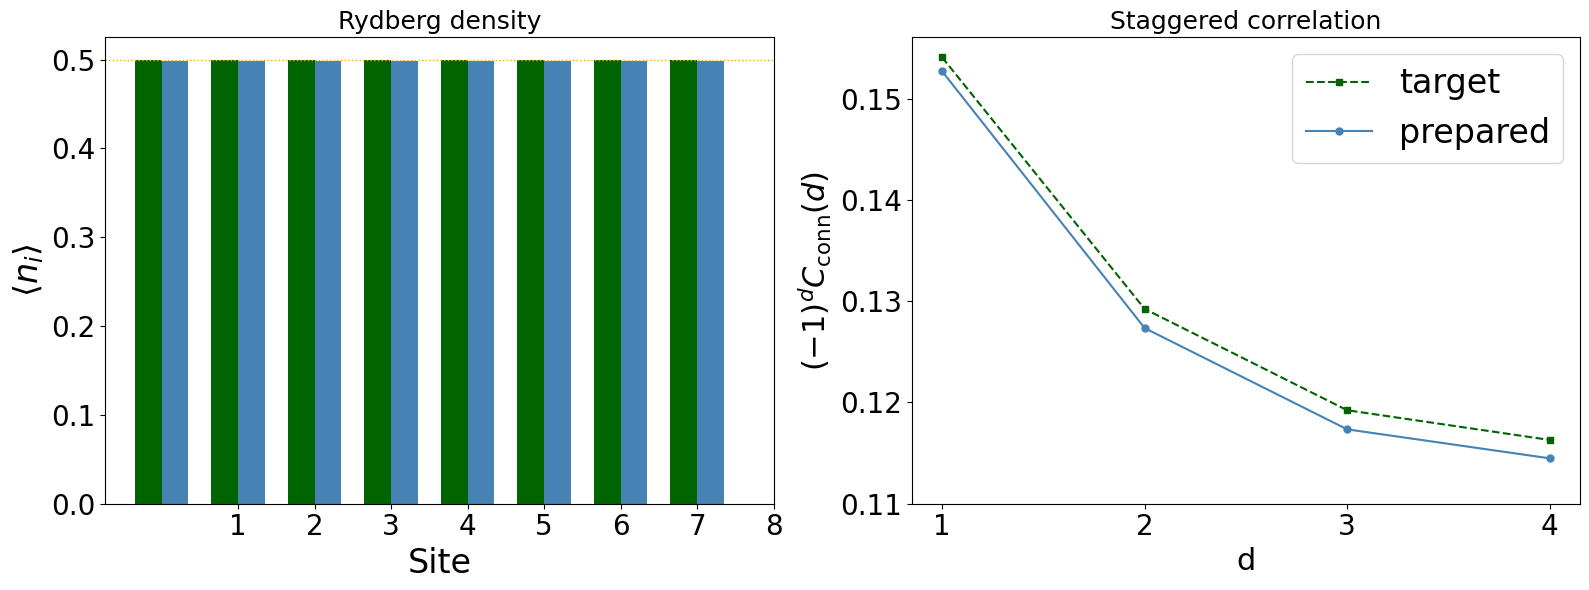

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Rydberg density ---
ax = axes[0]
x = np.arange(N)
y = [round(x,2) for x in np.arange(0,0.55,0.1)]
w = 0.35
ax.bar(x - w/2, occ_t, w, color='darkgreen', label='target')
ax.bar(x + w/2, occ_p, w, color='steelblue', label='prepared')
ax.axhline(0.5, color='orange', ls=':', lw=1, label=r'$\langle n\rangle=1/2$')
ax.set_xlabel('Site',size=24)
ax.set_ylabel(r'$\langle n_i \rangle$',size=24)
ax.set_xticks(x+1,x+1,size=20)
ax.set_yticks(y,y,size=20)
ax.set_title('Rydberg density',size=18)

# --- Staggered correlations ---
ax = axes[1]
max_d = N // 2
dists = np.arange(1, max_d + 1)
stag_t = np.array([(-1)**d * np.mean([conn_t[i, (i+d) % N] for i in range(N)]) for d in dists])
stag_p = np.array([(-1)**d * np.mean([conn_p[i, (i+d) % N] for i in range(N)]) for d in dists])
ax.plot(dists, stag_t, 's--', color='darkgreen', ms=5, label='target')
ax.plot(dists, stag_p, 'o-',  color='steelblue', ms=5, label='prepared')
ax.set_xlabel('d',size=22)
ax.set_ylabel(r'$(-1)^d C_{\mathrm{conn}}(d)$',size=22)
x = range(1,N//2+1)
y = [round(x,2) for x in np.arange(0.11,0.155,0.01)]
ax.set_xticks(x,x,size=20)
ax.set_yticks(y,y,size=20)
ax.set_title('Staggered correlation',size=18)
ax.legend(fontsize=24)

plt.tight_layout()
plt.show()

## Conclusion

We successfully prepared the critical ground state of the 1D Transverse-Field Ising Model on a ring of 8 atoms using a quasi-adiabatic tangent sweep in **qoolqit**'s Rydberg analog model. The high fidelity with the ED target confirms that the schedule is effective even near the critical point where the energy gap is small.